In [1]:
import numpy as np
from scipy.signal import find_peaks
import sys
import os
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils/')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/bond_based/')

from plot_utils import plot_cluster_size_distribution, analyze_bond_network, plot_rdfs, plot_3d_cluster_with_graph
from bondmodifier_utils import canonical_cluster_workflow, import_file, summarize_bonds

# Import standardized plotting functions
from standardized_plots import (
    plot_coordination_histograms as std_plot_coordination_histograms,
    plot_graph_structure,
    plot_cluster_size_distribution as std_plot_cluster_size_distribution,
    plot_3d_graph_components,
    plot_3d_graph_components_pu_only as std_plot_3d_graph_components_pu_only,
    setup_plot_style,
    get_standard_colors,
    extract_positions_from_data,
    extract_names_from_data,
)
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

from shell_utils import (
    get_species_densities_from_data,
    calculate_coordination_number,
    calculate_coordination_number_vs_r,
    plot_coordination_number_vs_r_with_shell,
    detect_proper_shells
)


In [2]:
# get_species_densities_from_data function moved to shell_utils.py


In [3]:
# calculate_coordination_number function moved to shell_utils.py


In [4]:
# User inputs
infile = "/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T1100K/dump.lammpstrj"
rdf_samples = 100  # adjust for speed/accuracy

In [5]:
from bond_based.bondmodifier_utils import canonical_cluster_workflow_rdfs_only


pipe = import_file(infile, multiple_frames=True)
print(f"Loaded trajectory with {pipe.source.num_frames} frames")

# Set up standardized plotting style
setup_plot_style()
print("Standardized plotting style configured")

# Still construct all bonds (Voronoi and NaCl) but only cluster Pu atoms
result = canonical_cluster_workflow_rdfs_only(
    pipeline=pipe,
    rdf_samples=rdf_samples
)

r = result["rdf"]
cutoffs = result["pair_cutoffs"]
print("Pairwise cutoffs:", cutoffs)

Loaded trajectory with 14615 frames
Standardized plotting style configured
Pairwise cutoffs: {('Pu', 'Cl'): 3.9354099581612783, ('Pu', 'Na'): 6.419025016922944, ('Pu', 'Pu'): 6.2014689534593925, ('Cl', 'Pu'): 3.9354099581612783, ('Cl', 'Na'): 4.190203891248118, ('Cl', 'Cl'): 6.049791833679462, ('Na', 'Pu'): 6.419025016922944, ('Na', 'Cl'): 4.190203891248118, ('Na', 'Na'): 6.3406478383858165}


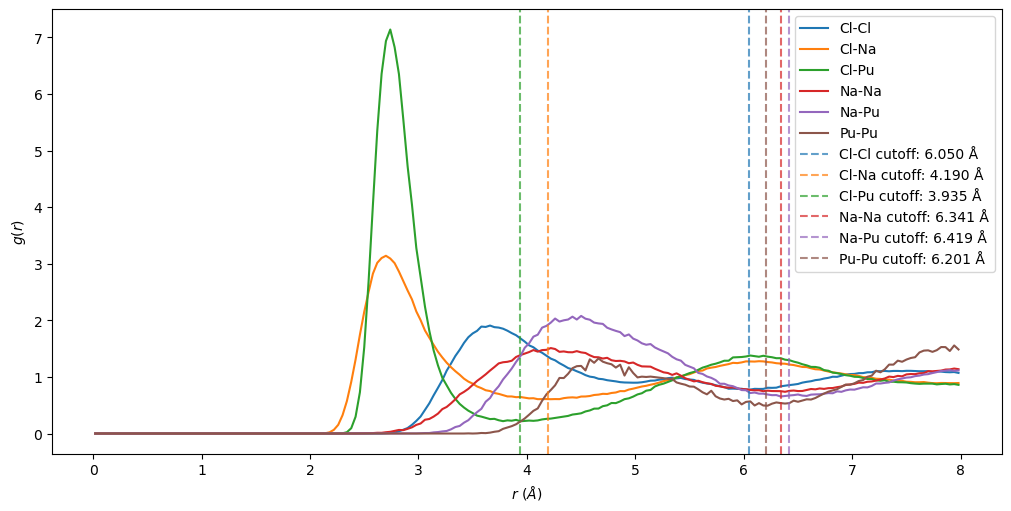

In [6]:
plot_rdfs(result["rdf"], cutoffs=cutoffs,figsize=(10, 5))

In [7]:
# calculate_coordination_number_vs_r function moved to shell_utils.py


In [8]:
# plot_coordination_number_vs_r_with_shell function moved to shell_utils.py
# This version supports shell_cutoff parameter


COORDINATION NUMBER AS A FUNCTION OF R
Pu-Cl coordination number at cutoff (3.935 Å): 40.945
R range: 0.020 to 7.980 Å
Number of points: 200


/tmp/ipykernel_253368/1787466056.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  cn_values[i] = np.trapz(integrand, r_integration)


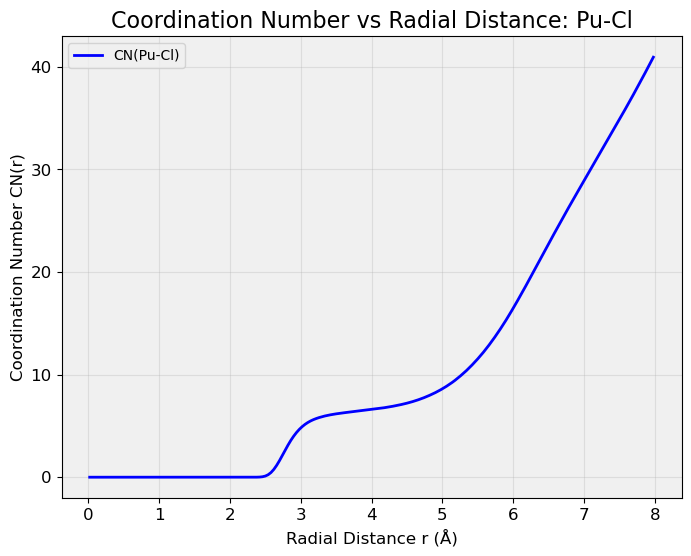

In [9]:
# Example: Calculate CN(r) for Pu-Cl pair using current data
print("=" * 60)
print("COORDINATION NUMBER AS A FUNCTION OF R")
print("=" * 60)

# Get current data
current_rdf = result["rdf"]
current_cutoffs = result["pair_cutoffs"]
current_densities = get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))

rmax=10.0
# Calculate CN(r) for Pu-Cl pair
r_pucl, cn_pucl = calculate_coordination_number_vs_r(
    current_rdf["r"], 
    current_rdf["Cl-Pu"], 
    current_densities["Cl"],
    r_max=rmax
)

print(f"Pu-Cl coordination number at cutoff ({current_cutoffs[('Pu', 'Cl')]:.3f} Å): {cn_pucl[-1]:.3f}")
print(f"R range: {r_pucl[0]:.3f} to {r_pucl[-1]:.3f} Å")
print(f"Number of points: {len(r_pucl)}")

from matplotlib import pyplot as plt
# Plot the result
ax=plot_coordination_number_vs_r(r_pucl, cn_pucl, "Pu-Cl", r_max=rmax)
plt.show()

In [10]:
cn_pucl

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [11]:
from bond_based.bondmodifier_utils import gaussian_smooth, find_first_shell_minimum

In [12]:
# detect_proper_shells function moved to shell_utils.py


In [13]:
def shell_cutoffs(rdfs):
    """
    Calculate shell cutoffs based on coordination number and radial distance.
    
    Args:
        r: Radial distance array


SyntaxError: incomplete input (1951642054.py, line 2)

In [ ]:
first_deriv = np.gradient(cn_pucl, r_pucl)

In [ ]:
detect_proper_shells(first_deriv)

NameError: name 'detect_proper_shells' is not defined

In [ ]:
current_rdf["r"][89]

np.float64(3.58)

In [ ]:
cn_pucl[89]

np.float64(6.254421833901042)